In [2]:
pip install gurobipy

In [1]:
from gurobipy import *
import numpy as np

import matplotlib.pyplot as plt
import networkx as nx

np.random.seed(33)

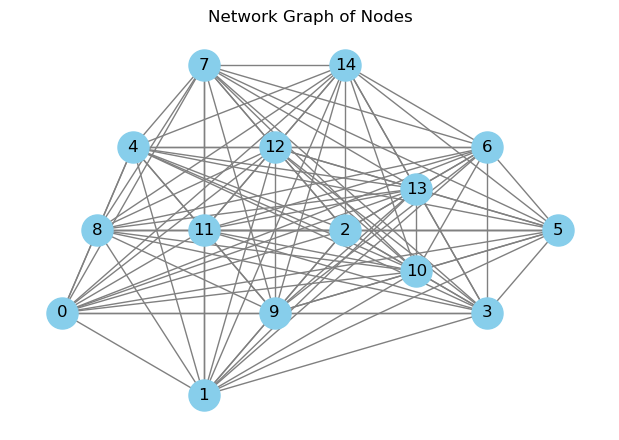

In [2]:
#These are x and y coordinates, stored as different lists, for 15 points (they could be thought of as latitude / longitudes)
x_coordinates = [1, 3, 5, 7, 2, 8, 7, 3, 1.5, 4, 6, 3, 4, 6, 5]
y_coordinates = [2, 1, 3, 2, 4, 3, 4, 5, 3, 2, 2.5, 3, 4, 3.5, 5]

Distance=[]

#This computes the Euclidean distance between all pairs of points
Distance=[[round(((x_coordinates[i]-x_coordinates[j])**2+(y_coordinates[i]-y_coordinates[j])**2)**0.5,2) for j in range(len(x_coordinates))] for i in range(len(x_coordinates))]

n = len(Distance)

# Create a graph
G = nx.Graph()

# Add nodes with their positions
for i, (x, y) in enumerate(zip(x_coordinates, y_coordinates)):
    G.add_node(i, pos=(x, y))

# Connect each node (assuming full connectivity)
for i in range(len(x_coordinates)):
    for j in range(i + 1, len(x_coordinates)):
        G.add_edge(i, j)

# Get positions
pos = nx.get_node_attributes(G, 'pos')

# Draw the network
plt.figure(figsize=(6, 4))
nx.draw(G, pos, with_labels=True, node_color='skyblue', node_size=500, edge_color='gray')
plt.title("Network Graph of Nodes")
plt.show()


In [3]:
#Modeling MTZ with Gurobi
m = Model("TSP")

x = {}
for i in range(n):
    for j in range(n):
        x[i,j] = m.addVar(obj=Distance[i][j], vtype=GRB.BINARY, name='x('+str(i)+')('+str(j)+')' )
m.update()

#u decision variables: continuous variables used in indexing for MTZ formulation
u = {}
for i in range(n):
    if (i > 0):
        u[i] = m.addVar(vtype=GRB.CONTINUOUS, lb=1.0, ub=n-1, obj=0.0, name='u('+str(i)+')' )
    else:
        u[i] = m.addVar(vtype=GRB.CONTINUOUS, lb=0, ub=0, obj=0.0, name='u('+str(i)+')' )
        #The above assigns u[0] to zero via its lb and ub

m.update()

#Constraints
#1: Each job has an arriving arc
for j in range(n):
    m.addConstr(quicksum(x[i,j] for i in range(n)) == 1)

#2: Each job has a departing arc
for i in range(n):
    m.addConstr(quicksum(x[i,j] for j in range(n)) == 1)
    x[i,i].ub = 0

#3: Use MTZ constraints to forbid subtours
for i in range(n-1):
    for j in range(n-1):
        if (i != j):
            m.addConstr(u[j+1] >= u[i+1] + 1 - (n-1)*(1-x[i+1,j+1]))

m.modelSense = GRB.MINIMIZE

m.update()

m.write("MTZ.lp")

#solve
m.optimize()


# Print optimal sequence of TSP nodes (these are stored in the u variables)
print('The optimal sequence is:')
for i in range(n):
    print(u[i].x) #uses 1-based indexing (instead of 0-based)

Set parameter Username
Academic license - for non-commercial use only - expires 2026-09-08
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (win64)

CPU model: 13th Gen Intel(R) Core(TM) i9-13900H, instruction set [SSE2|AVX|AVX2]
Thread count: 14 physical cores, 20 logical processors, using up to 20 threads

Optimize a model with 212 rows, 240 columns and 996 nonzeros
Model fingerprint: 0x65bc3976
Variable types: 15 continuous, 225 integer (225 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+01]
  Objective range  [1e+00, 7e+00]
  Bounds range     [1e+00, 1e+01]
  RHS range        [1e+00, 1e+01]
Presolve removed 0 rows and 16 columns
Presolve time: 0.05s
Presolved: 212 rows, 224 columns, 1938 nonzeros
Variable types: 14 continuous, 210 integer (210 binary)
Found heuristic solution: objective 50.8100000

Root relaxation: objective 2.000000e+01, 43 iterations, 0.01 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unex

In [4]:
def extract_optimal_path(x, n):
    # Start from the first node (0)
    current_node = 0
    path = [current_node]

    # Repeat until the path returns to the starting node
    while True:
        # Find the next node in the path
        for j in range(n):
            if x[current_node, j].x > 0.5:  # Assuming binary decision variables
                current_node = j
                break
        if current_node == 0:  # If returned to the start, break the loop
            break
        path.append(current_node)

    return path

# After solving the model
optimal_path = extract_optimal_path(x, n)
print("Optimal path:", optimal_path)

Optimal path: [0, 8, 11, 4, 7, 12, 14, 13, 6, 5, 3, 10, 2, 9, 1]


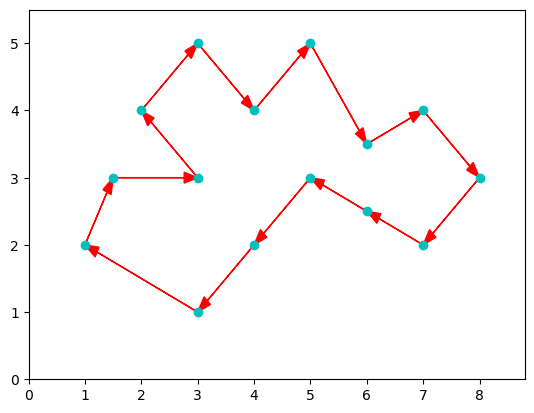

In [5]:
###############################################################################
#Extra: This code also plots the (x,y) pairs, as well as the optimal sequence #
###############################################################################

import matplotlib.pyplot as plt
import pprint

#Define plot sequence q[]
u1 = []
for i in range(n):
    u1.append(int(round(u[i].x,2)))

m = []
q = []

for i in range (n):
    m.append(i)

for i in range (n):
    q.append(i)

for i in range (n):
    q[(u1[i]-1)]=int(m[i])


def plotTSP(path1, points, num_iters=1):
    # Unpack the primary TSP path and transform it into a list of ordered coordinates
    x = []
    y = []
    for i in path1:
        x.append(points[i][0])
        y.append(points[i][1])

    plt.plot(x, y, 'co')

    # Set a scale for the arrow heads
    x_scale = float(max(x)) / float(50)

    # Draw the primary path for the TSP problem
    plt.arrow(x[-1], y[-1], (x[0] - x[-1]), (y[0] - y[-1]), head_width=x_scale, color='r', length_includes_head=True)
    for i in range(0, len(x) - 1):
        plt.arrow(x[i], y[i], (x[i + 1] - x[i]), (y[i + 1] - y[i]), head_width=x_scale, color='r', length_includes_head=True)

  # Set axis too slitghtly larger than the set of x and y
    plt.xlim(0, max(x) * 1.1)
    plt.ylim(0, max(y) * 1.1)
    plt.show()

# For Python to read a source file
if __name__ == '__main__':

#Pend coordinates to points
    points = []
    for i in range(0, len(x_coordinates)):
        points.append((x_coordinates[i], y_coordinates[i]))

#Create path order from u[i]
# Local Search operation
    path1 = []
    for i in range(n):
        path1.append(int(q[i]))

      # Run the function
    plotTSP(path1, points,1)

Nearest-Neighbor (greedy) tour (0-based): [0, 8, 4, 7, 12, 2, 10, 13, 6, 5, 3, 9, 1, 11, 12, 14, 0]
Tour length (greedy NN): 26.76


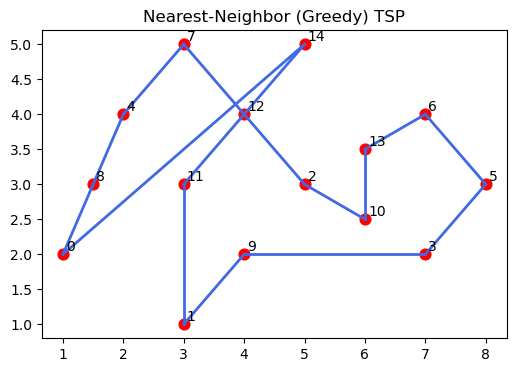

In [6]:
# Nearest-Neighbor (Greedy) TSP

#Builds a route by always visiting the nearest unvisited node next (nearest-neighbor heuristic)

from networkx.algorithms import approximation as approx

# Add weights
for i in range(n):
    for j in range(i + 1, n):
        G[i][j]["weight"] = Distance[i][j]
        G[j][i]["weight"] = Distance[i][j]

# Run greedy TSP (nearest neighbor)
tour = approx.traveling_salesman_problem(
    G,
    weight="weight",
    cycle=True,
    method=approx.traveling_salesman.greedy_tsp
)

# Compute length
def tour_length(route, dist):
    return sum(dist[route[i]][route[i+1]] for i in range(len(route)-1))

nn_length = tour_length(tour, Distance)

print("Nearest-Neighbor (greedy) tour (0-based):", tour)
print("Tour length (greedy NN):", round(nn_length, 2))

# Plot (single color for all arcs)
plt.figure(figsize=(6,4))
edge_color = "royalblue"     # choose any matplotlib color name or hex
for i in range(len(tour)-1):
    a, b = tour[i], tour[i+1]
    plt.plot(
        [x_coordinates[a], x_coordinates[b]],
        [y_coordinates[a], y_coordinates[b]],
        color=edge_color, linewidth=2
    )

# Draw points and labels
plt.scatter(x_coordinates, y_coordinates, c='red', s=60)
for i, (x, y) in enumerate(zip(x_coordinates, y_coordinates)):
    plt.text(x + 0.05, y + 0.05, str(i), fontsize=10)
plt.title("Nearest-Neighbor (Greedy) TSP")
plt.show()

Nearest-Neighbor (greedy) tour (0-based): [0, 1, 9, 2, 10, 13, 6, 5, 3, 12, 14, 7, 4, 11, 8, 0]
Tour length (greedy NN): 23.58


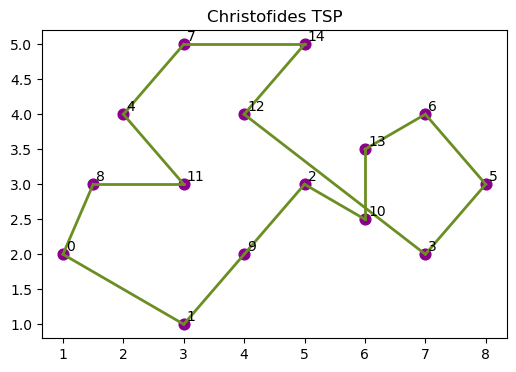

In [7]:
# Christofides

#Builds a minimum spanning tree, then matches odd-degree vertices and takes shortcuts.

from networkx.algorithms import approximation as approx

# Add weights
for i in range(n):
    for j in range(i + 1, n):
        G[i][j]["weight"] = Distance[i][j]
        G[j][i]["weight"] = Distance[i][j]

# Run Christo
tour = approx.traveling_salesman_problem(
    G,
    weight="weight",
    cycle=True,
    method=approx.traveling_salesman.christofides
)

# Compute length
def tour_length(route, dist):
    return sum(dist[route[i]][route[i+1]] for i in range(len(route)-1))

nn_length = tour_length(tour, Distance)

print("Nearest-Neighbor (greedy) tour (0-based):", tour)
print("Tour length (greedy NN):", round(nn_length, 2))

# Plot (single color for all arcs)
plt.figure(figsize=(6,4))
edge_color = "olivedrab"     # choose any matplotlib color name or hex
for i in range(len(tour)-1):
    a, b = tour[i], tour[i+1]
    plt.plot(
        [x_coordinates[a], x_coordinates[b]],
        [y_coordinates[a], y_coordinates[b]],
        color=edge_color, linewidth=2
    )

# Draw points and labels
plt.scatter(x_coordinates, y_coordinates, c='darkmagenta', s=60)
for i, (x, y) in enumerate(zip(x_coordinates, y_coordinates)):
    plt.text(x + 0.05, y + 0.05, str(i), fontsize=10)
plt.title("Christofides TSP")
plt.show()